# Modeling Customer Trade-offs with a Choice Model

## Scenario
A product team surveyed customers on subscription bundle preferences.
Each respondent chose among three alternatives across multiple tasks.
Your task is to fit a choice model, interpret which features drive selection,
and build a price sensitivity chart to support product decisions.

## Your task
You will produce:
1. A fitted logistic regression (choice model) with interpretable coefficients
2. A coefficient plot showing feature importance by absolute magnitude
3. A price sensitivity chart (average choose-rate by price level)
4. A markdown list of the **top 3 drivers** with directional interpretation

## Requirements
- Use `choice_conjoint_tasks.csv`
- Encode categorical features (`support`, `ads`, `offline_download`) before fitting
- Model outcome: `chosen` column (1 = chosen, 0 = not chosen)
- Identify the top 3 drivers by absolute coefficient magnitude and state their direction

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from pathlib import Path
PROJECT_DIR = Path(r"/content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project")
DATA_DIR = PROJECT_DIR / "Project_Data"
if not DATA_DIR.exists():
    DATA_DIR = Path("Project_Data")

CHOICE_PATH  = DATA_DIR / "choice_conjoint_tasks.csv"
BUNDLES_PATH = DATA_DIR / "candidate_bundles.csv"
ADOPT_PATH   = DATA_DIR / "observational_offer_adoption.csv"
SURVEY_PATH  = DATA_DIR / "survey_value_drivers.csv"
MMM_PATH     = DATA_DIR / "marketing_weekly_channels.csv"
print("DATA_DIR:", DATA_DIR.resolve())

DATA_DIR: /content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project/Project_Data


In [3]:
# ── Step 1: Load and inspect the choice data ──────────────────────────────
df = pd.read_csv(CHOICE_PATH)
print(df.shape)
df.head()

(24000, 11)


,respondent_id,segment_true,task_id,alternative,price_usd,storage_gb,support,ads,family_seats,offline_download,chosen
0,1,PowerUser,1,A,8,50,Standard,Ads,1,Yes,0
1,1,PowerUser,1,B,12,200,Standard,NoAds,4,No,0
2,1,PowerUser,1,C,5,1000,Standard,Ads,4,No,1
3,1,PowerUser,2,A,5,200,Priority,Ads,1,No,0
4,1,PowerUser,2,B,5,200,Standard,NoAds,4,Yes,1


In [4]:
# ── Step 2: Encode features and build the feature matrix ──────────────────
# Encode categorical attributes; keep all levels so we can set reference explicitly
df_enc = pd.get_dummies(df, columns=['support','ads','offline_download'], drop_first=False)

# Drop reference levels (Standard support, Ads present, No offline)
df_enc.drop(columns=['support_Standard','ads_Ads','offline_download_No'], inplace=True)

# Feature columns: numeric attributes + binary attribute flags
feat_cols = ['price_usd','storage_gb','family_seats',
             'support_Priority','ads_NoAds','offline_download_Yes']

# Feature matrix and binary target
X = df_enc[feat_cols].astype(float)
y = df_enc['chosen']

In [5]:
# ── Step 3: Fit the choice model ──────────────────────────────────────────
# Fit logistic regression — coefficients are proportional to part-worth utilities
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X, y)

# Extract and sort coefficients by absolute magnitude
coefs = pd.Series(model.coef_[0], index=feat_cols)
coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index)
print(coefs_sorted.round(4))

ads_NoAds               0.8188
support_Priority        0.4930
price_usd              -0.3572
offline_download_Yes    0.2913
family_seats            0.1571
storage_gb              0.0024
dtype: float64


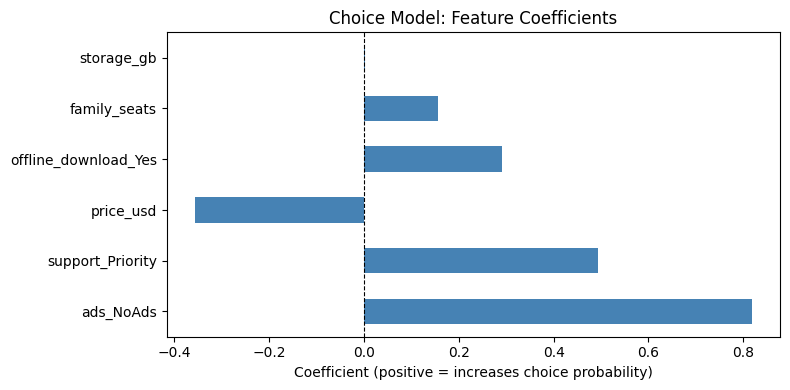

In [6]:
# ── Step 4: Coefficient plot ──────────────────────────────────────────────
# Visualize feature coefficients; length = strength, direction = sign
plt.figure(figsize=(8, 4))
coefs_sorted.plot(kind='barh', color='steelblue')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel("Coefficient (positive = increases choice probability)")
plt.title("Choice Model: Feature Coefficients")
plt.tight_layout()
plt.show()

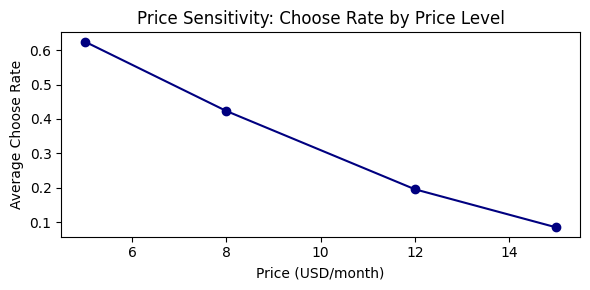

In [7]:
# ── Step 5: Price sensitivity chart ──────────────────────────────────────
# Average choose-rate by price level shows how demand drops with price
price_sens = df.groupby('price_usd')['chosen'].mean().reset_index()
plt.figure(figsize=(6, 3))
plt.plot(price_sens['price_usd'], price_sens['chosen'], marker='o', color='navy')
plt.xlabel("Price (USD/month)")
plt.ylabel("Average Choose Rate")
plt.title("Price Sensitivity: Choose Rate by Price Level")
plt.tight_layout()
plt.show()

## Reflection

In the markdown cell below, list the **top 3 feature drivers** (by absolute coefficient magnitude).
For each driver, state its direction and write one sentence on what this implies for product decisions.

**Format:**
1. **Feature name** (coefficient ≈ X): [direction] → [decision implication]
2. ...
3. ...

In [8]:
# Solution: identify top 3 by absolute coefficient — then interpret direction
top3 = coefs_sorted.head(3)
for feat, val in top3.items():
    direction = "increases" if val > 0 else "decreases"
    print(f"{feat}: coef={val:.4f}  →  {direction} choice probability")

ads_NoAds: coef=0.8188  →  increases choice probability
support_Priority: coef=0.4930  →  increases choice probability
price_usd: coef=-0.3572  →  decreases choice probability
